Setup & Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import drive
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import os
import random
import itertools
from sklearn.metrics import roc_curve, auc

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Device Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Hyperparameters
BATCH_SIZE = 64
EPOCHS = 20
LEARNING_RATE = 0.0005
MARGIN = 1.0  # Hyperparameter for Triplet Loss

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda


Load Data & Split Users

We split by User ID to ensure the model learns to verify signatures it has never seen before (User-Independent Testing).

In [3]:
# Path to your processed data
DATA_PATH = "/content/drive/MyDrive/Processed_GPDS_CEDAR"

print(f"Loading data from: {DATA_PATH} ...")

# Load Arrays
X_data = np.load(os.path.join(DATA_PATH, "X_signatures.npy"))
y_data = np.load(os.path.join(DATA_PATH, "y_labels.npy"))
user_ids = np.load(os.path.join(DATA_PATH, "user_ids.npy"))

print(f"X_data shape: {X_data.shape}")

# --- 1. Split Users into Train (80%) and Test (20%) ---
unique_users = np.unique(user_ids)
np.random.seed(42) # Reproducibility
np.random.shuffle(unique_users)

split_idx = int(0.8 * len(unique_users))
train_users = unique_users[:split_idx]
test_users = unique_users[split_idx:]

print(f"Train Users: {len(train_users)}")
print(f"Test Users: {len(test_users)}")

# --- 2. Helper: Map Indices to Users ---
# We need this to quickly find 'genuine' and 'forged' indices for any user
def get_user_map(target_users, all_ids, all_labels):
    user_map = {uid: {'genuine': [], 'forged': []} for uid in target_users}

    for i, (uid, label) in enumerate(zip(all_ids, all_labels)):
        if uid in user_map:
            key = 'genuine' if label == 1 else 'forged'
            user_map[uid][key].append(i)
    return user_map

train_map = get_user_map(train_users, user_ids, y_data)
test_map = get_user_map(test_users, user_ids, y_data)

print("User maps created.")

Loading data from: /content/drive/MyDrive/Processed_GPDS_CEDAR ...
X_data shape: (7451, 224, 224, 1)
Train Users: 164
Test Users: 41
User maps created.


Data Generation (Triplets & Pairs)

Training: Generates (Anchor, Positive, Negative) triplets.

Testing: Generates (Image1, Image2, Label) pairs for standard evaluation.

In [4]:
# --- TRIPLET GENERATOR (For Training) ---
def create_triplets(user_map):
    triplets = []

    print("Generating Training Triplets...")
    for uid in tqdm(user_map.keys()):
        gens = user_map[uid]['genuine']
        forgs = user_map[uid]['forged']

        if len(gens) < 2 or len(forgs) == 0:
            continue

        # Strategy: For every Genuine (Anchor) + Genuine (Positive) pair,
        # pick a random Forgery (Negative)

        # All unique combinations of genuine signatures
        # Using combinations ensures we don't just duplicate (A,B) and (B,A) unless desired
        pos_pairs = list(itertools.permutations(gens, 2))

        for anchor, positive in pos_pairs:
            # Random hard negative (forgery)
            negative = random.choice(forgs)
            triplets.append([anchor, positive, negative])

    return np.array(triplets)

# --- PAIR GENERATOR (For Testing/Evaluation) ---
def create_test_pairs(user_map):
    pairs = []
    labels = []

    print("Generating Test Pairs...")
    for uid in user_map.keys():
        gens = user_map[uid]['genuine']
        forgs = user_map[uid]['forged']

        # Positive Pairs (Gen-Gen)
        pos_combs = list(itertools.combinations(gens, 2))
        for p in pos_combs:
            pairs.append(p)
            labels.append(1) # Same writer

        # Negative Pairs (Gen-Forg) - Balanced
        if len(pos_combs) > 0:
            neg_combs = list(itertools.product(gens, forgs))
            if len(neg_combs) > len(pos_combs):
                neg_combs = random.sample(neg_combs, len(pos_combs))

            for p in neg_combs:
                pairs.append(p)
                labels.append(0) # Different (Forgery)

    return np.array(pairs), np.array(labels)

# Generate Data
train_triplets = create_triplets(train_map)
test_pairs, test_labels = create_test_pairs(test_map)

print(f"Training Triplets: {train_triplets.shape}")
print(f"Testing Pairs: {test_pairs.shape}")

Generating Training Triplets...


  0%|          | 0/164 [00:00<?, ?it/s]

Generating Test Pairs...
Training Triplets: (52496, 3)
Testing Pairs: (13896, 2)


Custom Datasets (Triplet & Pair)

We need two dataset classes: one for loading triplets (Training) and one for loading pairs (Testing).

In [5]:
# --- Augmentation ---
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor()
])

# --- 1. Triplet Dataset (Train) ---
class TripletDataset(Dataset):
    def __init__(self, triplets, x_data, transform=None):
        self.triplets = triplets
        self.x_data = x_data
        self.transform = transform

    def __getitem__(self, idx):
        anc_idx, pos_idx, neg_idx = self.triplets[idx]

        img_a = self.x_data[anc_idx]
        img_p = self.x_data[pos_idx]
        img_n = self.x_data[neg_idx]

        # Fix channel dim if (H, W, 1) -> (H, W) for PIL
        if img_a.ndim == 3:
            img_a, img_p, img_n = img_a.squeeze(), img_p.squeeze(), img_n.squeeze()

        if self.transform:
            img_a = self.transform(img_a)
            img_p = self.transform(img_p)
            img_n = self.transform(img_n)

        return img_a, img_p, img_n

    def __len__(self):
        return len(self.triplets)

# --- 2. Pair Dataset (Test) ---
class PairDataset(Dataset):
    def __init__(self, pairs, labels, x_data, transform=None):
        self.pairs = pairs
        self.labels = labels
        self.x_data = x_data
        self.transform = transform

    def __getitem__(self, idx):
        idx1, idx2 = self.pairs[idx]
        img1, img2 = self.x_data[idx1], self.x_data[idx2]

        if img1.ndim == 3:
            img1, img2 = img1.squeeze(), img2.squeeze()

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, torch.tensor(self.labels[idx], dtype=torch.float32)

    def __len__(self):
        return len(self.pairs)

# Loaders
train_ds = TripletDataset(train_triplets, X_data, transform=train_transform)
test_ds = PairDataset(test_pairs, test_labels, X_data, transform=test_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

Define Embedding Models

These models now output a single embedding vector. The "Siamese" nature comes from passing three images through the same network instance

In [6]:
# --- 1. Custom CNN ---
class CustomEmbeddingNet(nn.Module):
    def __init__(self):
        super(CustomEmbeddingNet, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 5), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 5), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Flatten()
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 25 * 25, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128) # Output Embedding
        )

    def forward(self, x):
        x = self.cnn(x)
        x = self.fc(x)
        return F.normalize(x, p=2, dim=1) # Normalize embedding

# --- 2. ResNet-18 ---
class ResNetEmbeddingNet(nn.Module):
    def __init__(self):
        super(ResNetEmbeddingNet, self).__init__()
        resnet = models.resnet18(pretrained=True)
        resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.features = nn.Sequential(*list(resnet.children())[:-1])
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(resnet.fc.in_features, 512),
            nn.ReLU(),
            nn.Linear(512, 128)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.fc(x)
        return F.normalize(x, p=2, dim=1)

# --- 3. EfficientNet-B0 ---
class EfficientNetEmbeddingNet(nn.Module):
    def __init__(self):
        super(EfficientNetEmbeddingNet, self).__init__()
        effnet = models.efficientnet_b0(pretrained=True)
        effnet.features[0][0] = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)
        self.features = effnet.features
        self.avgpool = effnet.avgpool
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(1280, 512),
            nn.ReLU(),
            nn.Linear(512, 128)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.flatten(x)
        x = self.fc(x)
        return F.normalize(x, p=2, dim=1)

Triplet Training Loop

This function trains the network using TripletMarginLoss.

In [7]:
def train_triplet_model(model, name):
    print(f"\n=== Training {name} with Triplet Loss ===")
    model = model.to(device)

    # TRIPLET LOSS
    criterion = nn.TripletMarginLoss(margin=MARGIN, p=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    losses = []

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0.0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)

        for anchor, positive, negative in loop:
            anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)

            optimizer.zero_grad()

            # Forward pass all three
            emb_a = model(anchor)
            emb_p = model(positive)
            emb_n = model(negative)

            # Calculate Loss
            loss = criterion(emb_a, emb_p, emb_n)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            loop.set_postfix(loss=loss.item())

        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        print(f"Epoch {epoch+1} Loss: {avg_loss:.4f}")

    # Save
    torch.save(model.state_dict(), os.path.join(DATA_PATH, f"{name}_triplet.pth"))
    return model, losses

Evaluation (Using Pairs)

Even though we trained on triplets, we evaluate on pairs to calculate Accuracy and EER.

In [8]:
def evaluate_model(model, name):
    print(f"\n--- Evaluating {name} ---")
    model.eval()

    distances = []
    y_true = []

    with torch.no_grad():
        for img1, img2, label in test_loader:
            img1, img2 = img1.to(device), img2.to(device)

            emb1 = model(img1)
            emb2 = model(img2)

            # Euclidean Distance
            dist = F.pairwise_distance(emb1, emb2).cpu().numpy()

            distances.extend(dist)
            y_true.extend(label.numpy())

    distances = np.array(distances)
    y_true = np.array(y_true)

    # ROC Curve
    # Use -distance because lower distance = higher similarity (Positive class)
    fpr, tpr, thresholds = roc_curve(y_true, -distances)
    roc_auc = auc(fpr, tpr)

    # EER Calculation
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fpr - fnr))
    eer = fpr[eer_idx]

    print(f"AUC: {roc_auc:.4f}")
    print(f"EER: {eer:.4f}")

    return roc_auc, eer

Run All Models


=== Training CustomCNN with Triplet Loss ===


Epoch 1/10:   0%|          | 0/821 [00:00<?, ?it/s]

Epoch 1 Loss: 0.4561


Epoch 2/10:   0%|          | 0/821 [00:00<?, ?it/s]

Epoch 2 Loss: 0.1773


...

Epoch 8 Loss: 0.0349


Epoch 9/10:   0%|          | 0/821 [00:00<?, ?it/s]

Epoch 9 Loss: 0.0309


Epoch 10/10:   0%|          | 0/821 [00:00<?, ?it/s]

Epoch 10 Loss: 0.0275

--- Evaluating CustomCNN ---
AUC: 0.7695
EER: 0.3132


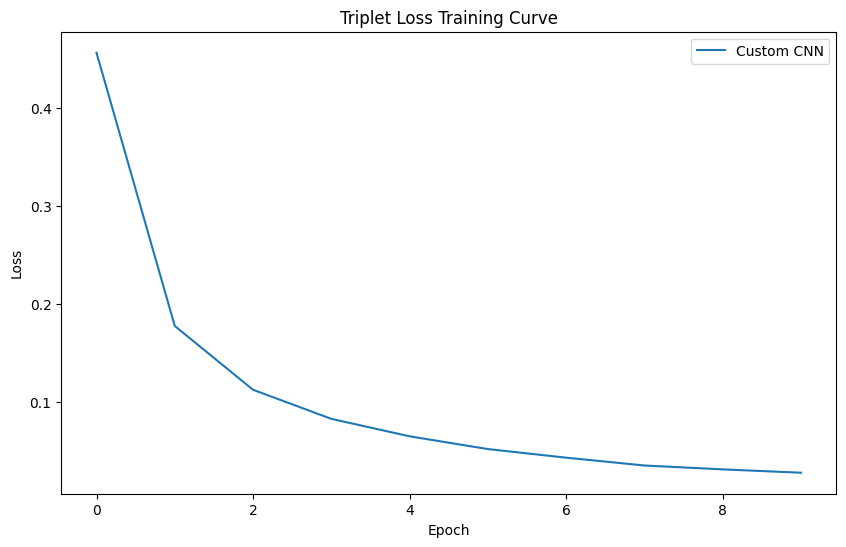

In [9]:
EPOCHS = 10
# 1. Custom CNN
custom_net = CustomEmbeddingNet()
custom_net, custom_losses = train_triplet_model(custom_net, "CustomCNN")
evaluate_model(custom_net, "CustomCNN")


# Plot Losses
plt.figure(figsize=(10, 6))
plt.plot(custom_losses, label='Custom CNN')
plt.title('Triplet Loss Training Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Find Optimal Threshold & Visualize Separation

Calculating distances on Test Set...

Results:
Optimal Distance Threshold: 1.0581
EER at Threshold: 0.3132


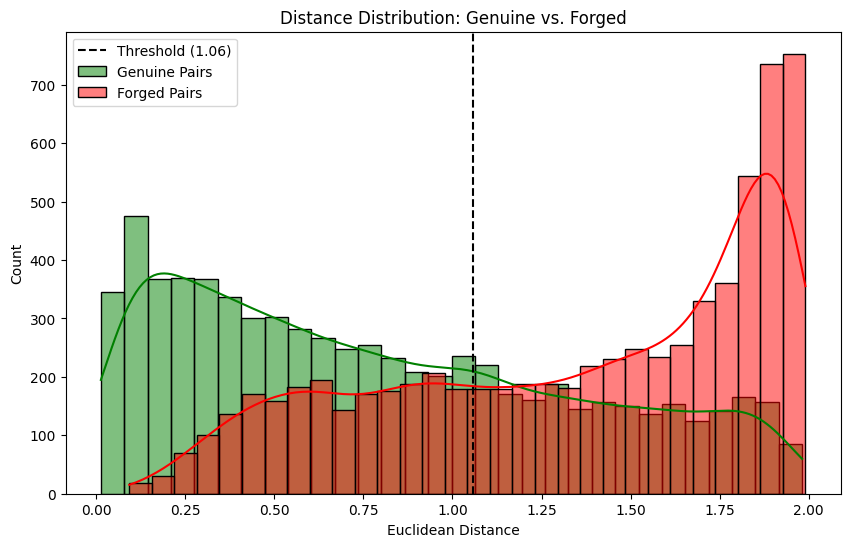

In [10]:
import seaborn as sns

def analyze_model_performance(model, loader, device):
    model.eval()
    distances = []
    labels = []

    print("Calculating distances on Test Set...")
    with torch.no_grad():
        for img1, img2, label in loader:
            img1, img2 = img1.to(device), img2.to(device)
            emb1 = model(img1)
            emb2 = model(img2)
            dist = F.pairwise_distance(emb1, emb2).cpu().numpy()
            distances.extend(dist)
            labels.extend(label.numpy())

    distances = np.array(distances)
    labels = np.array(labels)

    # 1. Find Optimal Threshold (Equal Error Rate)
    # We look for the threshold where False Acceptance Rate (FAR) ≈ False Rejection Rate (FRR)
    fpr, tpr, thresholds = roc_curve(labels, -distances)
    fnr = 1 - tpr
    eer_index = np.nanargmin(np.abs(fpr - fnr))
    optimal_threshold = -thresholds[eer_index]
    eer = fpr[eer_index]

    print(f"\nResults:")
    print(f"Optimal Distance Threshold: {optimal_threshold:.4f}")
    print(f"EER at Threshold: {eer:.4f}")

    # 2. Plot Distance Distributions
    plt.figure(figsize=(10, 6))
    sns.histplot(distances[labels==1], label='Genuine Pairs', kde=True, color='green', alpha=0.5, bins=30)
    sns.histplot(distances[labels==0], label='Forged Pairs', kde=True, color='red', alpha=0.5, bins=30)
    plt.axvline(x=optimal_threshold, color='black', linestyle='--', label=f'Threshold ({optimal_threshold:.2f})')
    plt.title("Distance Distribution: Genuine vs. Forged")
    plt.xlabel("Euclidean Distance")
    plt.legend()
    plt.show()

    return optimal_threshold

# Run analysis on the trained CustomNet
# Make sure 'custom_net' is the model you just trained
threshold = analyze_model_performance(custom_net, test_loader, device)

Run Inference (Visual Verification)

Testing with Threshold: 0.5000


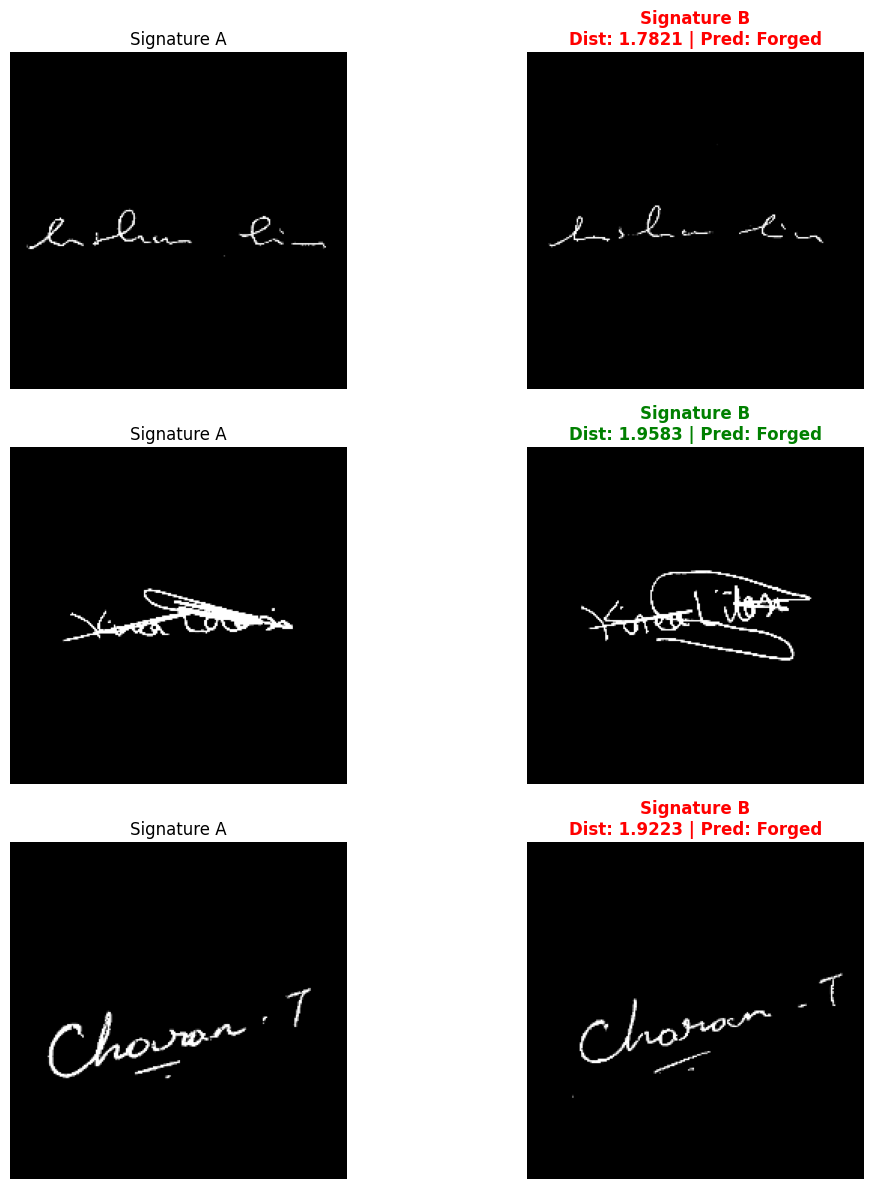

In [14]:
def verify_sample(model, dataset, threshold, count=3):
    model.eval()
    indices = np.random.choice(len(dataset), count, replace=False)

    plt.figure(figsize=(12, 4*count))

    for i, idx in enumerate(indices):
        img1, img2, label = dataset[idx]

        # Prepare for Model (Add batch dim)
        input1 = img1.unsqueeze(0).to(device)
        input2 = img2.unsqueeze(0).to(device)

        # Inference
        with torch.no_grad():
            emb1 = model(input1)
            emb2 = model(input2)
            distance = F.pairwise_distance(emb1, emb2).item()

        # Decision
        prediction = "Genuine" if distance < threshold else "Forged"
        actual = "Genuine" if label == 1 else "Forged"
        color = "green" if prediction == actual else "red"

        # Visualization
        # Convert tensors back to numpy for plotting (C, H, W) -> (H, W)
        img1_show = img1.squeeze().cpu().numpy()
        img2_show = img2.squeeze().cpu().numpy()

        plt.subplot(count, 2, 2*i + 1)
        plt.imshow(img1_show, cmap='gray')
        plt.title("Signature A")
        plt.axis('off')

        plt.subplot(count, 2, 2*i + 2)
        plt.imshow(img2_show, cmap='gray')
        plt.title(f"Signature B\nDist: {distance:.4f} | Pred: {prediction}", color=color, fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Run the demo
print(f"Testing with Threshold: {threshold:.4f}")
verify_sample(custom_net, test_ds, threshold)

Accuracy and Confusion Matrix

Evaluating model...

--- Final Results (Threshold: 0.5000) ---
Accuracy: 65.15%

Classification Report:
              precision    recall  f1-score   support

      Forged       0.60      0.92      0.72      6948
     Genuine       0.82      0.39      0.53      6948

    accuracy                           0.65     13896
   macro avg       0.71      0.65      0.63     13896
weighted avg       0.71      0.65      0.63     13896



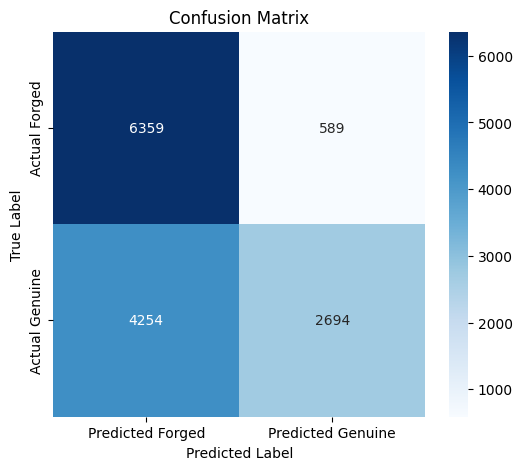

In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
def evaluate_metrics(model, loader, device, threshold):
    model.eval()
    y_true = []
    y_pred = []
    distances = []

    print("Evaluating model...")
    with torch.no_grad():
        for img1, img2, label in loader:
            img1, img2 = img1.to(device), img2.to(device)

            # Forward pass
            emb1 = model(img1)
            emb2 = model(img2)
            dist = F.pairwise_distance(emb1, emb2).cpu().numpy()

            # Collect data
            distances.extend(dist)
            y_true.extend(label.numpy())

            # Make binary predictions based on threshold
            # Distance < Threshold -> Genuine (1)
            # Distance > Threshold -> Forged (0)
            preds = (dist < threshold).astype(int)
            y_pred.extend(preds)

    # --- 1. Accuracy & Report ---
    accuracy = accuracy_score(y_true, y_pred)
    print(f"\n--- Final Results (Threshold: {threshold:.4f}) ---")
    print(f"Accuracy: {accuracy*100:.2f}%")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["Forged", "Genuine"]))

    # --- 2. Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Forged', 'Predicted Genuine'],
                yticklabels=['Actual Forged', 'Actual Genuine'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Run evaluation on your trained CustomNet
# ensure you pass the 'threshold' variable calculated in the previous step
evaluate_metrics(custom_net, test_loader, device, threshold)